# 03 · Features

A **feature** is an input the model learns from. In this notebook we:

1. Add **weather data** and line it up correctly with the solar data
2. Add **sun position** and **clear-sky sunlight**, using the physics library `pvlib`
3. Build the feature table, using only information that would really be available at forecast time

**Weather source:** Open-Meteo Historical Weather API (based on ECMWF reanalysis data),
for the Huang Engineering Center at Stanford. Downloaded with `python -m src.weather`.

In [8]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data import load_hourly
from src.features import build_features, load_weather, FEATURE_SETS

FIGURES = ROOT / "results" / "figures"
PROCESSED = ROOT / "data" / "processed"

y = load_hourly().tz_convert("UTC")
raw_weather = pd.read_csv(ROOT / "data" / "raw" / "weather_openmeteo_2017_2019.csv", index_col="time", parse_dates=True)
raw_weather.head()

,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,precipitation,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,shortwave_radiation,direct_radiation,diffuse_radiation
time,,,,,,,,,,,,,
2017-01-01 00:00:00+00:00,10.1,64,3.6,1009.4,0.0,0,0,0,0,6.8,203.0,148.0,55.0
2017-01-01 01:00:00+00:00,8.6,72,3.9,1010.2,0.0,5,5,0,0,5.9,52.0,32.0,20.0
2017-01-01 02:00:00+00:00,7.7,75,3.6,1010.7,0.0,0,0,0,0,5.1,0.0,0.0,0.0
2017-01-01 03:00:00+00:00,7.3,76,3.4,1011.1,0.0,7,7,1,0,10.7,0.0,0.0,0.0
2017-01-01 04:00:00+00:00,7.0,80,3.7,1011.6,0.0,8,8,0,0,8.0,0.0,0.0,0.0


## Step 1 · Line up the weather with the solar data

Our solar data labels each hour by its **start**: the row "12:00" covers 12:00–13:00.
Open-Meteo labels sunlight and rain by the **end** of the hour: its "13:00" covers 12:00–13:00.

If we don't fix this, every sunlight value is off by one hour. Let's **check it with data** instead
of trusting the documentation: move the weather's sunlight by −2 to +2 hours and see where it
matches the solar power best.

In [9]:
shifts = [-2, -1, 0, 1, 2]
match = []
for s in shifts:
    both = pd.concat([y, raw_weather["shortwave_radiation"].shift(s)], axis=1).dropna()
    match.append(both.corr().iloc[0, 1])

pd.DataFrame({"shift (hours)": shifts, "correlation": np.round(match, 3)})

/var/folders/kb/lt2r69g55jv0ps4pqrws8xj00000gn/T/ipykernel_11598/850053977.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  both = pd.concat([y, raw_weather["shortwave_radiation"].shift(s)], axis=1).dropna()


,shift (hours),correlation
0,-2,0.895
1,-1,0.962
2,0,0.932
3,1,0.812
4,2,0.627


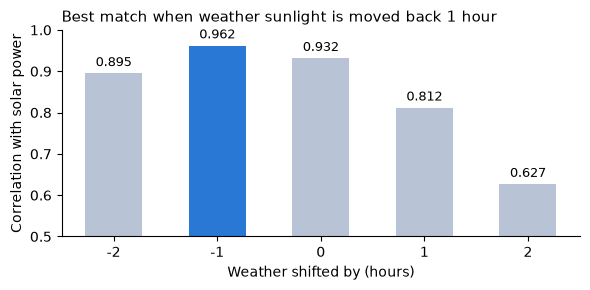

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
colors = ["#2a78d6" if s == -1 else "#b8c4d6" for s in shifts]
bars = ax.bar([str(s) for s in shifts], match, color=colors, width=0.55)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.set_xlabel("Weather shifted by (hours)")
ax.set_ylabel("Correlation with solar power")
ax.set_title("Best match when weather sunlight is moved back 1 hour", loc="left", fontsize=11)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "03_weather_alignment.png", dpi=130)
plt.show()

**Result:** the best match is at **−1 hour** (0.96), which confirms the documentation.
So `load_weather()` in `src/features.py` moves the "preceding hour" variables (sunlight and rain)
back one hour. Temperature, humidity, clouds and wind are snapshots at the start of the hour,
so they stay as they are.

## Step 2 · Sun position and clear-sky sunlight (pvlib)

`pvlib` is the standard open-source solar physics library. For any place and time it calculates:

- **Sun elevation:** how high the sun is in the sky (degrees)
- **Clear-sky GHI:** how much sunlight would reach the ground **if there were no clouds** (W/m²)

These are known **perfectly in advance**, because they're just physics. They give the model the
daily and seasonal curve for free, so it can focus on learning the effect of clouds.

In [11]:
X = build_features()
print(X.shape)
X.loc["2019-06-10 13:00":"2019-06-10 20:00",
      ["target", "sun_elevation", "clearsky_ghi", "pv_lag1", "obs_cloud_cover"]].round(2)

(24705, 38)


,target,sun_elevation,clearsky_ghi,pv_lag1,obs_cloud_cover
time,,,,,
2019-06-10 13:00:00+00:00,0.53,6.82,44.54,0.00,95.0
2019-06-10 14:00:00+00:00,2.76,17.94,224.81,0.53,98.0
2019-06-10 15:00:00+00:00,5.44,29.58,426.85,2.76,98.0
2019-06-10 16:00:00+00:00,12.56,41.45,615.45,5.44,98.0
2019-06-10 17:00:00+00:00,15.84,53.27,773.36,12.56,97.0
2019-06-10 18:00:00+00:00,19.54,64.50,888.36,15.84,11.0
2019-06-10 19:00:00+00:00,21.35,73.44,952.03,19.54,0.0
2019-06-10 20:00:00+00:00,20.61,74.87,959.80,21.35,74.0


(Times are in UTC: 13:00 UTC is 6 AM in California.)

## Step 3 · The four feature groups

Each row is one **target hour h**, the hour we want to predict. The question for every feature is:
**"Would I really know this at the end of hour h−1?"**

| Group | Features | Known at forecast time? |
|---|---|---|
| **time_sun** | hour and day of year (as sin/cos), sun elevation, clear-sky GHI | ✅ Yes, it's physics |
| **past_pv** | power 1, 2 and 24 hours ago, average of the last 3 hours, last hour's clear-sky index | ✅ Yes, already measured |
| **obs_weather** | weather in the **previous** hour (clouds, humidity, sunlight…) | ✅ Yes, already observed |
| **perfect_forecast_weather** | weather **during** hour h | ⚠️ No. It's like a *perfect* weather forecast |

**Why sin/cos for time?** Hour 23 and hour 0 are neighbours, but as plain numbers (23 vs 0) they look
far apart. Putting the hour on a circle with sin and cos keeps them close. The same goes for
31 December and 1 January.

**Why keep the "perfect forecast" group at all?** It answers a useful research question:
*"How much would a better weather forecast help?"* We'll use it only in one clearly labelled
**upper-bound** experiment, never for the main results.

In [12]:
for group, cols in FEATURE_SETS.items():
    print(f"{group:26s} {len(cols):2d} features: {', '.join(cols[:4])}{' ...' if len(cols) > 4 else ''}")

time_sun                    6 features: hour_sin, hour_cos, doy_sin, doy_cos ...
past_pv                     5 features: pv_lag1, pv_lag2, pv_lag24, csi_lag1 ...
obs_weather                13 features: obs_temperature_2m, obs_relative_humidity_2m, obs_dew_point_2m, obs_surface_pressure ...
perfect_forecast_weather   13 features: fc_temperature_2m, fc_relative_humidity_2m, fc_dew_point_2m, fc_surface_pressure ...


## Which features matter most?

A first look: the correlation of each feature with the target, during daylight only
(sun higher than 5°). Correlation only captures straight-line relationships, so this is a rough guide,
not a final answer. The models will tell us more.

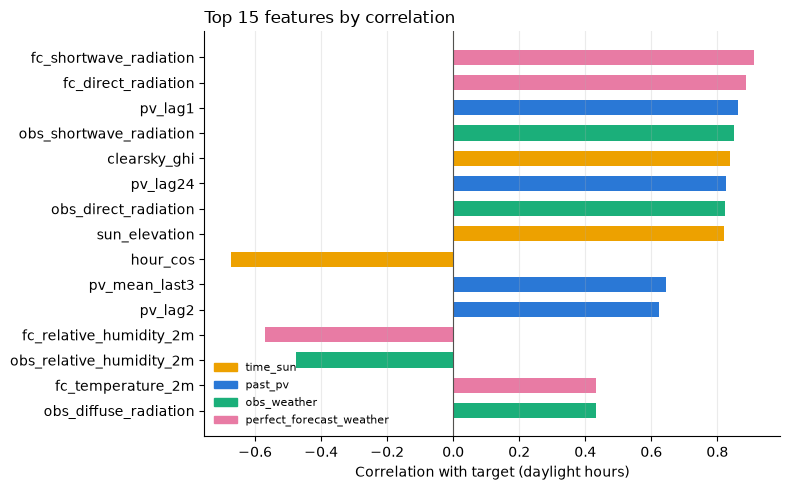

In [13]:
day = X["sun_elevation"] > 5
corr = X[day].corr()["target"].drop("target")
top = corr.reindex(corr.abs().sort_values(ascending=False).index)[:15]

group_of = {c: g for g, cols in FEATURE_SETS.items() for c in cols}
group_colors = {"time_sun": "#eda100", "past_pv": "#2a78d6", "obs_weather": "#1baf7a",
                "perfect_forecast_weather": "#e87ba4"}

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index[::-1], top.values[::-1], color=[group_colors[group_of[c]] for c in top.index[::-1]], height=0.6)
ax.axvline(0, color="#52514e", linewidth=0.8)
ax.set_xlabel("Correlation with target (daylight hours)")
ax.set_title("Top 15 features by correlation", loc="left")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in group_colors.values()]
ax.legend(handles, group_colors.keys(), loc="lower left", frameon=False, fontsize=8)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "03_feature_correlation.png", dpi=130)
plt.show()

**What we see:**

- The strongest single feature is **next hour's actual sunlight** (a "perfect forecast" feature, pink).
  That's expected, and it's exactly why we keep it out of the main models.
- Among the realistic features, **last hour's power** (`pv_lag1`) and **physics** (`clearsky_ghi`,
  `sun_elevation`) are strongest.
- **Clouds and humidity** are negatively correlated: more clouds means less power, as expected.

## Save the feature table

In [14]:
X.to_parquet(PROCESSED / "features_hourly.parquet")
print("Saved", X.shape, "to", (PROCESSED / "features_hourly.parquet").relative_to(ROOT))

Saved (24705, 38) to data/processed/features_hourly.parquet


**Next notebook:** `04_models.ipynb`. We train Linear Regression, Random Forest and Gradient Boosting
on these features, and compare them with smart persistence (RMSE 2.10 kWh on 2019).